# **1. Perkenalan Dataset**


Dataset yang digunakan pada eksperimen ini adalah Breast Cancer Wisconsin Diagnostic Dataset. Dataset ini berisi fitur numerik hasil pengukuran karakteristik inti sel dari citra fine needle aspirate massa payudara. Tujuan utama penggunaan dataset ini adalah membangun model klasifikasi untuk memprediksi apakah suatu sampel termasuk kelas malignant atau benign.

Dataset ini dipilih karena memiliki karakteristik tabular yang jelas, ukuran relatif ringan, dan cocok digunakan untuk membangun sistem machine learning berbasis MLOps. Dataset terdiri dari fitur-fitur numerik seperti mean radius, mean texture, mean perimeter, mean area, dan fitur statistik lainnya. Label target terdiri dari dua kelas, yaitu 0 dan 1.

Dalam proyek ini, dataset mentah disimpan sebagai `breast_cancer_raw.csv`. Setelah proses eksplorasi dan preprocessing dilakukan, dataset hasil preprocessing akan disimpan sebagai `breast_cancer_preprocessing.csv` dan digunakan pada tahap pelatihan model.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

print("Library berhasil di-import")

Library berhasil di-import


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
raw_dataset_path = "../breast_cancer_raw.csv"

df = pd.read_csv(raw_dataset_path)

print("Dataset berhasil dimuat")
print("Jumlah baris dan kolom:", df.shape)

df.head()

Dataset berhasil dimuat
Jumlah baris dan kolom: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# Menampilkan informasi umum dataset
print("Informasi Dataset:")
df.info()

print("\nJumlah baris dan kolom:")
print(df.shape)

print("\nDaftar kolom:")
print(df.columns.tolist())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothn

In [4]:
# Statistik deskriptif dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [5]:
# Mengecek missing value dan data duplikat
missing_values = df.isnull().sum()
duplicate_count = df.duplicated().sum()

print("Jumlah missing value per kolom:")
print(missing_values)

print("\nJumlah data duplikat:")
print(duplicate_count)

Jumlah missing value per kolom:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Jumlah data duplikat:
0


Distribusi kelas target:
target
0    212
1    357
Name: count, dtype: int64


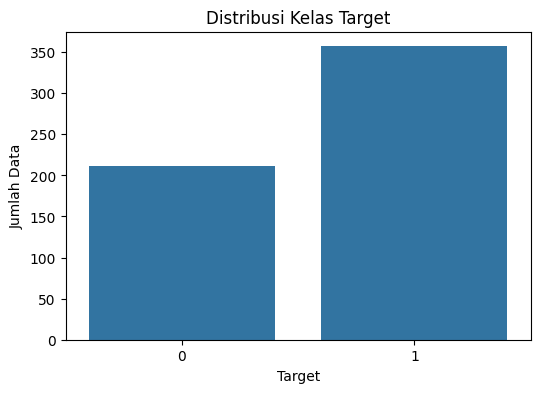

In [6]:
# Distribusi kelas target
target_distribution = df["target"].value_counts().sort_index()

print("Distribusi kelas target:")
print(target_distribution)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target")
plt.title("Distribusi Kelas Target")
plt.xlabel("Target")
plt.ylabel("Jumlah Data")
plt.show()

Korelasi fitur terhadap target:
target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742

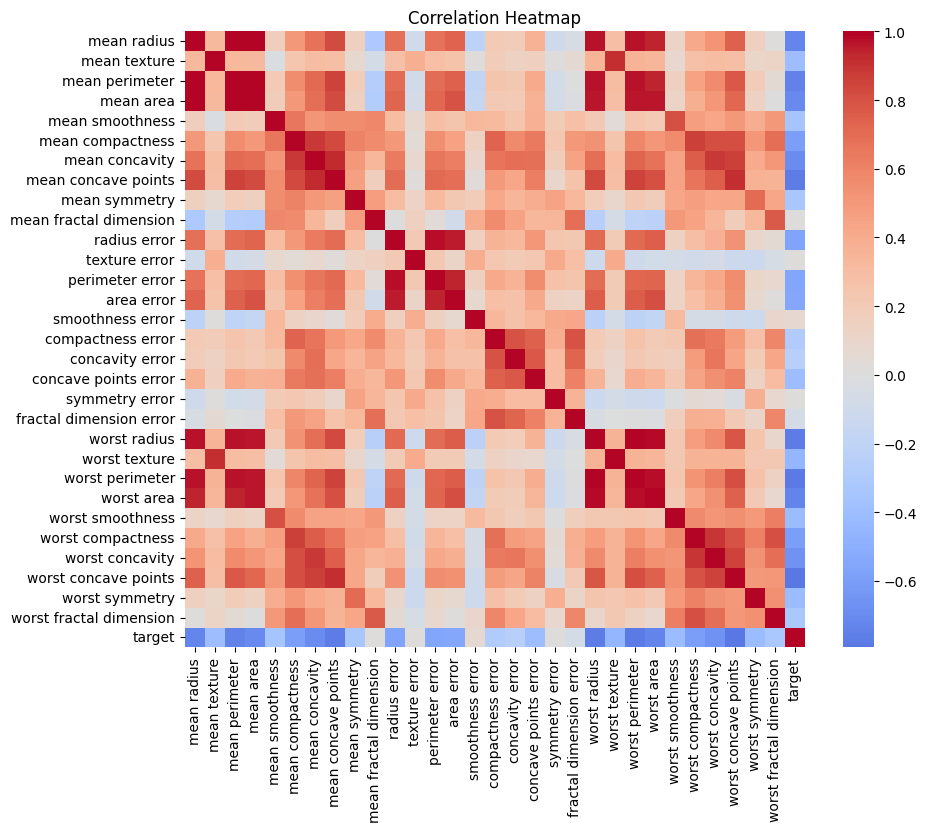

In [7]:
# Analisis korelasi fitur terhadap target
correlation_with_target = df.corr(numeric_only=True)["target"].sort_values(ascending=False)

print("Korelasi fitur terhadap target:")
print(correlation_with_target)

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

### Insight EDA

Berdasarkan hasil eksplorasi data, dataset memiliki 569 baris dan 31 kolom yang terdiri dari 30 fitur numerik dan 1 kolom target. Kolom target memiliki dua kelas, yaitu 0 dan 1, sehingga masalah yang diselesaikan merupakan klasifikasi biner.

Hasil pengecekan missing value menunjukkan bahwa dataset tidak memiliki nilai kosong. Selain itu, pengecekan data duplikat dilakukan untuk memastikan tidak ada baris data yang berulang dan berpotensi memengaruhi kualitas pelatihan model.

Distribusi target menunjukkan bahwa jumlah data pada kelas 1 lebih banyak dibandingkan kelas 0. Meskipun terdapat perbedaan jumlah antar kelas, dataset masih dapat digunakan untuk pelatihan model klasifikasi. Analisis korelasi juga menunjukkan bahwa beberapa fitur memiliki hubungan cukup kuat terhadap target, sehingga fitur-fitur numerik pada dataset relevan untuk digunakan dalam proses modelling.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [8]:
# Membuat salinan dataset agar data asli tetap aman
df_preprocessed = df.copy()

# Menghapus data duplikat jika ada
df_preprocessed = df_preprocessed.drop_duplicates()

# Mengubah nama kolom agar lebih aman digunakan dalam proses modelling
df_preprocessed.columns = (
    df_preprocessed.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Memastikan kolom target berada dalam format integer
df_preprocessed["target"] = df_preprocessed["target"].astype(int)

print("Jumlah baris dan kolom setelah preprocessing:", df_preprocessed.shape)
print("\nLima baris pertama dataset hasil preprocessing:")
df_preprocessed.head()

Jumlah baris dan kolom setelah preprocessing: (569, 31)

Lima baris pertama dataset hasil preprocessing:


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [9]:
# Memisahkan fitur dan target
X = df_preprocessed.drop(columns=["target"])
y = df_preprocessed["target"]

print("Jumlah fitur:", X.shape[1])
print("Jumlah data:", X.shape[0])
print("Distribusi target:")
print(y.value_counts())

Jumlah fitur: 30
Jumlah data: 569
Distribusi target:
target
1    357
0    212
Name: count, dtype: int64


In [10]:
# Membagi dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test:", y_test.shape)

Ukuran X_train: (455, 30)
Ukuran X_test: (114, 30)
Ukuran y_train: (455,)
Ukuran y_test: (114,)


In [11]:
# Melakukan standardisasi fitur numerik
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Scaling berhasil dilakukan")
print("Contoh data latih setelah scaling:")
X_train_scaled.head()

Scaling berhasil dilakukan
Contoh data latih setelah scaling:


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718,-0.968359,-1.102032,0.281062,-0.113231,-0.704861,-0.440938,-0.743949,-0.629805,0.000748,-0.991573,-0.693760,-0.983284,-0.591579,-0.428972,-1.034094,-0.623497,-1.070773,-0.876534,-0.169982,-1.038836,-1.078995,-1.350527,-0.352658,-0.541380
1,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288,1.519852,1.994664,-0.293045,-0.320180,0.127567,-0.381383,0.094075,0.317524,0.639656,0.087389,0.708451,1.182150,0.426212,0.074797,1.228342,-0.092833,1.187467,1.104386,1.517001,0.249655,1.178594,1.549916,0.191078,-0.173739
2,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154,-1.092292,-1.243358,0.434395,-0.429247,-0.254445,1.237130,-0.338634,-0.413827,0.520240,-0.833114,-1.006736,-1.857894,1.356046,-1.006560,-0.973231,-1.036772,-1.008044,-0.834168,-1.097823,-1.167260,-1.282241,-1.707442,-0.307734,-1.213033
3,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762,-0.129729,-0.098605,0.555635,0.029395,-0.531049,-1.262281,-0.411682,-0.436600,-0.393580,-0.129997,-0.219965,-0.527278,-0.269450,-0.316623,-0.251266,-1.369643,-0.166633,-0.330292,0.234006,0.096874,-0.087521,-0.344838,0.242198,-0.118266
4,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099,-0.798502,-0.684484,0.737495,-0.457213,-0.498529,1.322961,-0.440597,-0.521457,-0.174225,-0.628196,-0.581187,-0.278344,1.528534,-0.313022,-0.801135,0.079230,-0.824381,-0.741830,-0.911367,-0.984612,-0.933190,-0.777604,0.555118,-0.761639


In [12]:
# Menyimpan dataset hasil preprocessing
preprocessed_dataset_path = "breast_cancer_preprocessing.csv"

df_preprocessed.to_csv(preprocessed_dataset_path, index=False)

print(f"Dataset hasil preprocessing berhasil disimpan: {preprocessed_dataset_path}")
print("Ukuran dataset hasil preprocessing:", df_preprocessed.shape)

Dataset hasil preprocessing berhasil disimpan: breast_cancer_preprocessing.csv
Ukuran dataset hasil preprocessing: (569, 31)


### Insight Data Preprocessing

Tahapan preprocessing dilakukan dengan membuat salinan dataset, menghapus data duplikat, menstandarkan nama kolom menjadi format lowercase dan snake_case, serta memastikan kolom target bertipe integer. Berdasarkan hasil pengecekan sebelumnya, dataset tidak memiliki missing value, sehingga tidak diperlukan imputasi nilai kosong.

Dataset kemudian dipisahkan menjadi fitur dan target. Untuk eksperimen manual, data dibagi menjadi data latih dan data uji menggunakan stratified split agar proporsi kelas target tetap terjaga. StandardScaler diterapkan pada fitur numerik dengan metode fit hanya pada data latih, kemudian transform pada data uji untuk menghindari data leakage.

Dataset hasil preprocessing disimpan sebagai `breast_cancer_preprocessing.csv`. File ini akan digunakan pada tahap berikutnya, yaitu pembangunan model machine learning dengan MLflow.